In [1]:
"""
Write a Python program to draw (visualize) the architecture of a Neural Network used to classify fraudulent and non-fraudulent credit card transactions.

Assume the fraud detection dataset contains the following input features:

TransactionAmount
TransactionTime
MerchantCategory
CustomerAge
AccountBalance
NumberOfTransactionsToday
Fraud (0 = Genuine, 1 = Fraud)
"""

'\nWrite a Python program to draw (visualize) the architecture of a Neural Network used to classify fraudulent and non-fraudulent credit card transactions.\n\nAssume the fraud detection dataset contains the following input features:\n\nTransactionAmount\nTransactionTime\nMerchantCategory\nCustomerAge\nAccountBalance\nNumberOfTransactionsToday\nFraud (0 = Genuine, 1 = Fraud)\n'

In [2]:
import pandas as pd

dataset_file = 'ps-3.csv'

# Prepare the dataset. (Dataset is randomly generated)
try:
    df = pd.read_csv(dataset_file)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found!")

df.head()

Dataset loaded successfully.


,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,AccountBalance,NumberOfTransactionsToday,Fraud
0,3748.53,23,7,25,23857.14,15,1
1,9507.39,19,10,53,41937.20,8,1
2,7321.28,10,10,25,10293.62,2,0
3,5988.59,16,6,75,48401.30,3,0
4,1564.41,7,5,77,35562.08,24,1


In [3]:
import matplotlib.pyplot as plt

# Visualization
def draw_neural_net(layer_sizes, feature_names):
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(-0.2, 1.4)
    ax.set_ylim(0, 1)
    ax.axis('off')

    v_spacing = 0.12
    h_spacing = 0.35

    node_coords = []
    labeled_hidden = False

    for i, layer_size in enumerate(layer_sizes):
        layer_nodes = []
        top = (layer_size - 1) * v_spacing / 2.0
        for j in range(layer_size):
            x = i * h_spacing + 0.1
            y = 0.5 + (top - j * v_spacing)
            layer_nodes.append((x, y))
        node_coords.append(layer_nodes)

    for i in range(len(node_coords) - 1):
        for start_node in node_coords[i]:
            for end_node in node_coords[i+1]:
                line = plt.Line2D([start_node[0], end_node[0]], [start_node[1], end_node[1]],
                                  c='gray', alpha=0.2, lw=0.8, zorder=1)
                ax.add_artist(line)

    for i, layer_size in enumerate(layer_sizes):
        for j in range(layer_size):
            x, y = node_coords[i][j]

            current_label = None

            # Input Layer (Blue)
            if i == 0:
                color = 'skyblue'
                if j == 0: current_label = "Input Layer (Features)"
                # Feature name text
                ax.text(x - 0.03, y, feature_names[j], ha='right', va='center',
                        fontsize=10, fontweight='bold')

            # Output Layer (Red)
            elif i == len(layer_sizes) - 1:
                color = 'lightcoral'
                if j == 0: current_label = "Output Layer (Prediction)"
                # Result text
                ax.text(x + 0.03, y, "Fraud Probability\n(0-1)", ha='left',
                        va='center', fontsize=10, fontweight='bold')

            # Hidden Layers (Green)
            else:
                color = 'lightgreen'
                if not labeled_hidden:
                    current_label = "Hidden Layers (Learning)"
                    labeled_hidden = True

            # Draw the neuron
            circle = plt.Circle((x, y), 0.025, color=color, ec='k', zorder=4, label=current_label)
            ax.add_artist(circle)

    plt.title("Neural Network Architecture: Credit Card Fraud Detection", fontsize=16, pad=10)

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3, fontsize=11, frameon=True)

    plt.show()

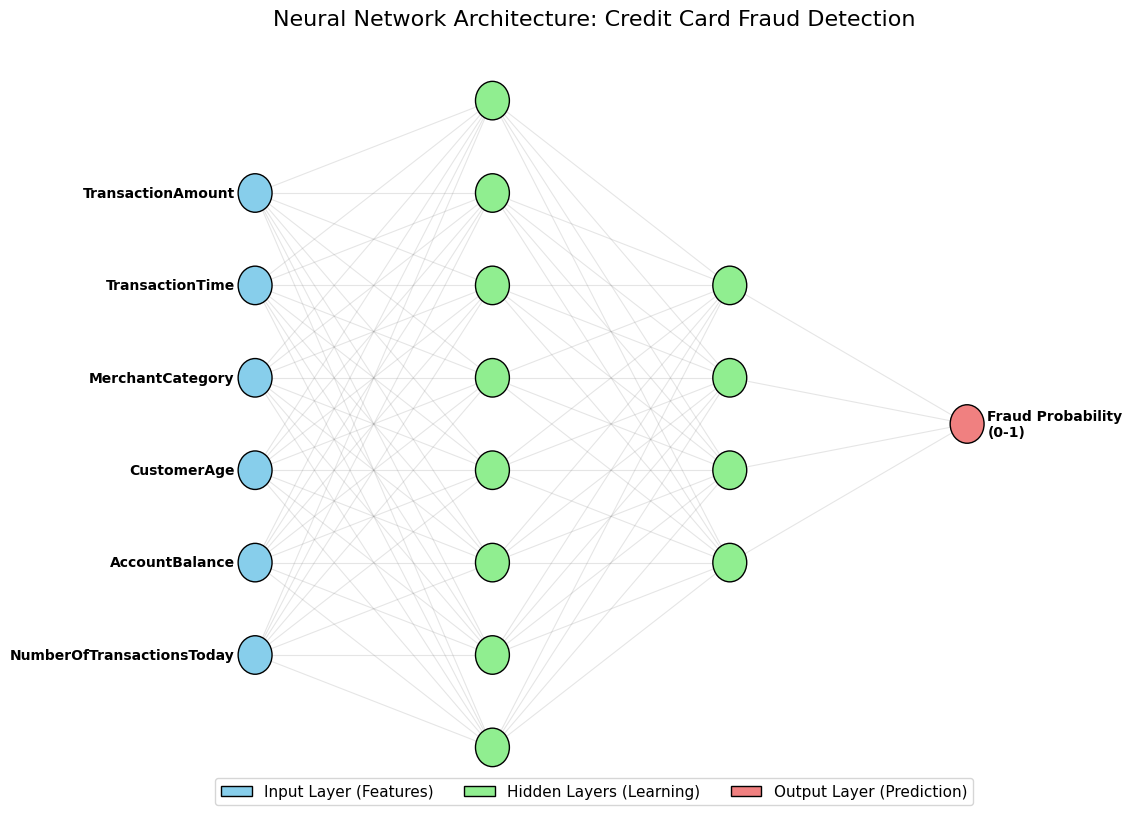

In [4]:
# Neural net architecture - Input Features: 6, Hidden Layers: [8, 4], Output: 1
layers = [6, 8, 4, 1]
feature_names = list(df.columns[:-1])

# Run the visualizer
draw_neural_net(layers, feature_names)

In [5]:
# Train and evaluate the model architecture on the dataset
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Fraud', axis=1)
y = df['Fraud']

# Train test split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Input

# Build the network (Architecture: 6-8-4-1)
model = Sequential([
    # Input layer
    Input(shape=(6,)),
    # First Hidden Layer
    Dense(8, activation='relu'),
    # Second Hidden Layer
    Dense(4, activation='relu'),
    # Output Layer
    Dense(1, activation='sigmoid')
])

In [13]:
# Compile and train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Training started...')
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=10, validation_split=0.2, verbose=0)
print('Training complete')

Training started...
Training complete


In [14]:
# Evaluate
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 87.50%
